In [1]:
# generate some linear looking data to test the normal equation
import numpy as np
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

In [2]:
# Take a look at the data 
print(f"X data generated: {X[:5]} \n")
print(f"Y data generated: {y[:5]}")

X data generated: [[1.17893486]
 [1.02116664]
 [1.3525961 ]
 [0.91096929]
 [0.42944771]] 

Y data generated: [[4.9838609 ]
 [6.80926441]
 [9.88517377]
 [5.86955246]
 [5.96014426]]


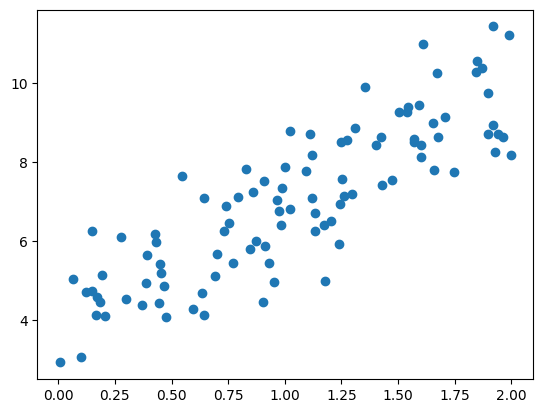

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
# calculate the hypothesis parameter 
X_b = np.c_[np.ones((100,1)),X] # add x0 =1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)

[[3.92854397]
 [2.96141979]]


The actual parameters are 4 and 3, we got 4.22 and 2.87 due to the Gaussian noises we added

In [5]:
# make predictions using theta 
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]# add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
print(y_predict)

[[3.92854397]
 [9.85138355]]


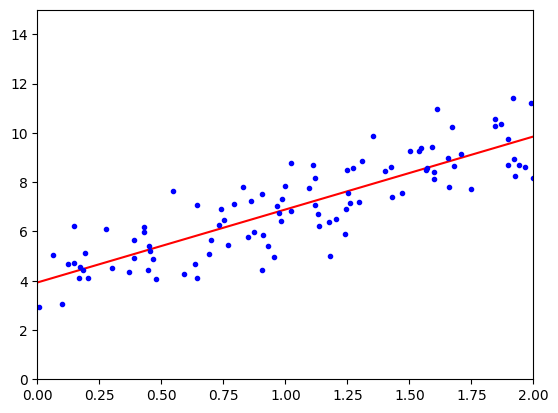

In [6]:
# plot the model's predictions
plt.plot(X_new, y_predict, "r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [7]:
# perform linear regression 
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(lin_reg.intercept_)
print(lin_reg.coef_)
print(lin_reg.predict(X_new))



[3.92854397]
[[2.96141979]]
[[3.92854397]
 [9.85138355]]


In [8]:
# use the least squares function instead
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.92854397],
       [2.96141979]])

In [9]:
np.linalg.pinv(X_b).dot(y)

array([[3.92854397],
       [2.96141979]])

In [10]:
# implement batch gradient descent
eta = 0.1 # learning rate 
n_iterations = 1000
m = 100

theta = np.random.randn(2,1) # random initialisation

for iteration in range(n_iterations):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients

print(theta)

[[3.92854397]
 [2.96141979]]


In [11]:
# implementing stochastic gradient descent 
n_epochs = 50
t0, t1 = 5,50 # learning schedule hyperparameters 

def learning_schedule(t):
  return t0 / (t + t1)

theta = np.random.randn(2,1) # random initialisation

for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi =X_b[random_index: random_index+1]
    yi =y[random_index: random_index+1]
    gradients = 2*xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch*m + i)
    theta = theta - eta * gradients

print(theta)

[[3.96262255]
 [2.92250089]]


To ensure the parameters are getting pulled towards the global optimum, we can shuffle the instances during training

In [12]:
# perform linear regression using SGD with sklearn
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X,y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([3.86436161]), array([2.95755762]))

Polynomial Regression 
Using a linear model to fit nonlinear data

In [13]:
# generate nonlinear data 
m = 100
X = 6 * np.random.rand(m, 1) -3 # add noise
y = 0.5 * X**2 + X +2 + np.random.randn(m,1) # quadratic eqn and added noise


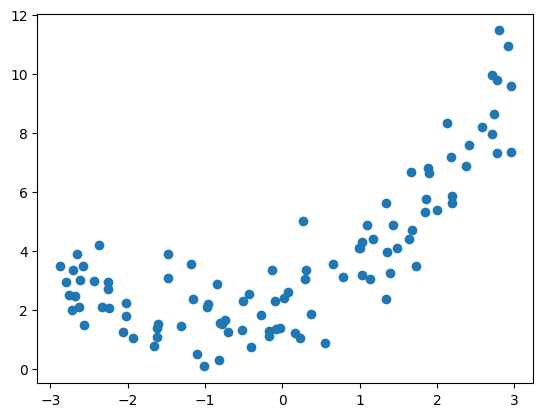

In [14]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [15]:
# use sklearn's polynomial class to transform the training data
# adding the square of each feature in the training set as new features
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree = 2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0], X_poly[0])

[2.70870462] [2.70870462 7.33708072]


In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[2.07116482] [[1.03563941 0.50896387]]


In [17]:
X_plot = np.linspace(-3,3,100).reshape(100,1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = lin_reg.predict(X_plot_poly)

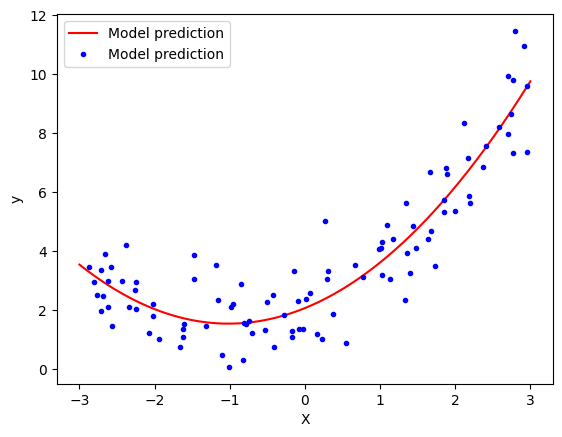

In [18]:
# plot the model's predictions
plt.plot(X_plot,y_plot, "r-", label="Model prediction")
plt.plot(X,y,"b.", label="Model prediction")
plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.show()

Learning curves

In [19]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, x, y):
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
  train_errors, val_errors = [], []

  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))
  
  plt.plot(np.sqrt(train_errors),"r-+", linewidth=2, label="train")
  plt.plot(np.sqrt(val_errors),"b-", linewidth=3, label="val")

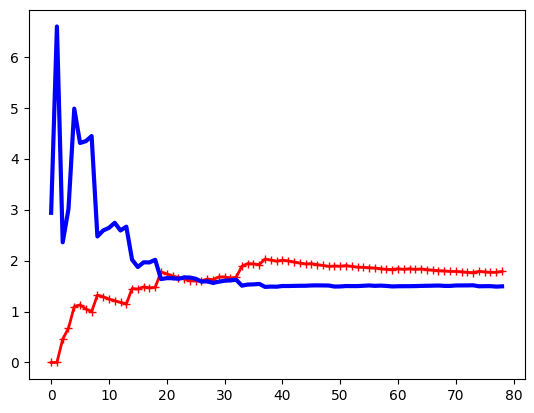

In [20]:
# plot the learning curves of the plain linear regression model 
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

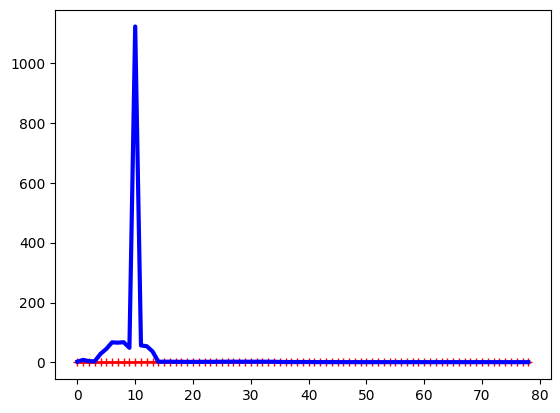

In [21]:
# plot the learning curves of a 10th degree polynomial model on the same data
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
  ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
  ("lin_reg", LinearRegression()),
])

plot_learning_curves(polynomial_regression, X, y)

In [22]:
# perform ridge regression using closed-form soltion
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver = "cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.23377429])

In [23]:
# use stochastic gradient descent 
sgd_reg = SGDRegressor(penalty='l2')
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([5.23088906])

In [25]:
# implement lasso regression
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([5.19136519])

In [26]:
# implement elastic net
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 0.1, l1_ratio=0.5) #half n half
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([5.19113552])